In [8]:
# Importing libraries
import numpy as np  # For random choice with probabilities
import matplotlib.pyplot as plt


In [18]:
# These are all the weather conditions we are considering
states = ["Sunny", "Cloudy", "Rainy","Windy"]
states

['Sunny', 'Cloudy', 'Rainy', 'Windy']

In [10]:
# This is our transition matrix
# Each row is the current weather
# Each column is the probability of moving to Sunny, Cloudy, Rainy or windy

transition_matrix = [
    [0.6, 0.15, 0.05,0.2],   # If today is Sunny → 60% Sunny, 15% Cloudy, 5% Rainy 20% windy tomorrow
    [0.2, 0.4, 0.2,0.2],     # If today is Cloudy → 20% Sunny, 40% Cloudy, 20% Rainy 20% windy
    [0.10, 0.25, 0.5, 0.15], # If today is Rainy → 10% Sunny, 25% Cloudy, 50% Rainy 15% windy
    [0.10, 0.25, 0.50, 0.15] # If today is Windy → 10% Sunny, 25% Cloudy, 50%Rainy 15% windy
]


In [11]:
# Let's assume the first day starts as Sunny
current_state = "Sunny"


In [12]:
# Create a dictionary to convert state name to index
# So we can use it with our matrix
state_to_index = {
    "Sunny": 0,
    "Cloudy": 1,
    "Rainy": 2,
    "Windy":3
}


In [19]:
def weather_prediction(initial_state, days):
    prediction = [initial_state]  # Start prediction with given initial state
    current_index = state_to_index[initial_state]  # Get the index for that state

    # Predict the weather for the next 'days' number of days
    for _ in range(days):
        # Choose the next weather state using the current state's row from the matrix
        next_state_index = np.random.choice(
            [0, 1, 2, 3],  # These are the possible states: Sunny, Cloudy, Rainy
            p=transition_matrix[current_index]  # Pick based on the correct probabilities
        )
        print(next_state_index)

        # Convert index back to state name
        next_state = states[next_state_index]
        print(next_state)
        # Add to our list of predictions
        prediction.append(next_state)

        # Update current index for the next loop
        current_index = next_state_index

    # Return the full list of predicted weathers
    return prediction


In [14]:
# Predict the weather for the next 15 days starting from Sunny
predicted_weather = weather_prediction("Sunny", 15)

# Show the result
print("Predicted Weather Over 15 Days:")
print(" → ".join(predicted_weather))


Predicted Weather Over 15 Days:
Sunny → Cloudy → Windy → Cloudy → Windy → Windy → Cloudy → Sunny → Windy → Rainy → Cloudy → Sunny → Windy → Rainy → Windy → Sunny


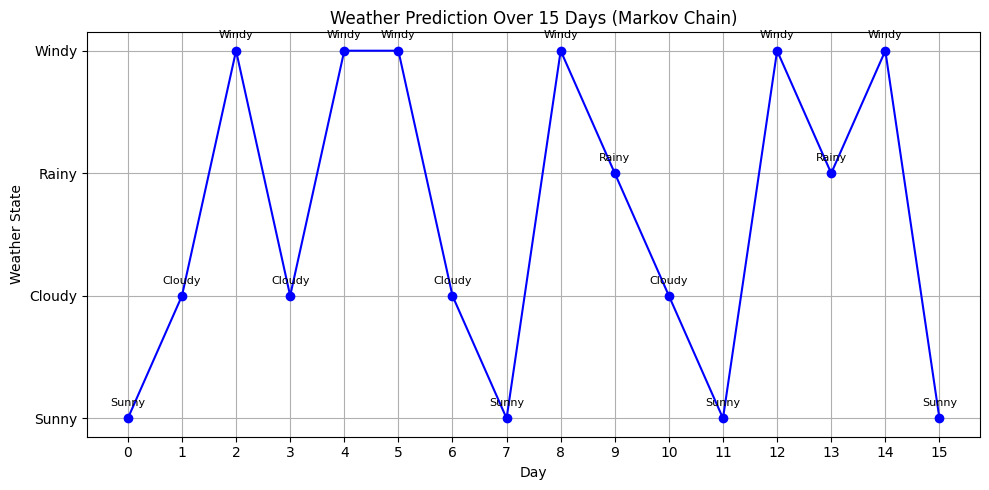

In [17]:
# Map states to numbers for plotting
state_to_num = {"Sunny": 0, "Cloudy": 1, "Rainy": 2, "Windy": 3}
num_to_state = {0: "Sunny", 1: "Cloudy", 2: "Rainy", 3: "Windy"}

# Convert predicted states to numeric
numeric_weather = [state_to_num[state] for state in predicted_weather]

# Create x-axis (days)
days = list(range(len(predicted_weather)))

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(days, numeric_weather, marker='o', linestyle='-', color='blue')

# Add labels
plt.yticks([0, 1, 2,3], ["Sunny", "Cloudy", "Rainy","Windy"])
plt.xticks(days)
plt.xlabel("Day")
plt.ylabel("Weather State")
plt.title("Weather Prediction Over 15 Days (Markov Chain)")
plt.grid(True)

# Annotate each point with state
for i, state in enumerate(predicted_weather):
    plt.text(i, numeric_weather[i] + 0.1, state, ha='center', fontsize=8)

plt.tight_layout()
plt.show()
